# AUTOBULL Darts Counting System 

bla bla bla

In [147]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from collections import defaultdict
from PIL import Image
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [106]:
# File paths
IMG_DIR = '../Data/snapshots'
LABELS_DIR = '../Data/bbox_labels'
POINTS_CSV = '../Data/points/points_labels.csv'


In [107]:
df = pd.read_csv(POINTS_CSV)

# Drop invalid rows
invalid_set_ids = ["set_024","set_144","set_145", "set_172", "set_213"]
df = df[~df['set_id'].isin(invalid_set_ids)].reset_index(drop=True)

score_lookup = df.set_index("set_id").to_dict(orient="index")

In [108]:
def load_yolo_labels(label_path, img_width, img_height, set_id, pfeil_nr):
    boxes = []
    with open(label_path, "r") as file:
        for line in file.readlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, x_center, y_center, w, h = map(float, parts[:5])
                x_center *= img_width
                y_center *= img_height
                w *= img_width
                h *= img_height
                x = x_center - w / 2
                y = y_center - h / 2

                score = score_lookup[set_id][f"score{pfeil_nr}"]
                zone = score_lookup[set_id][f"pfeil{pfeil_nr}_zone"]
                value = score_lookup[set_id][f"pfeil{pfeil_nr}_value"]


               
                    # Extract camera id from filename (assuming pattern like ..._cam1.txt)
                filename = os.path.basename(label_path)
                if "cam0" in filename:
                    cam_id = 1
                elif "cam2" in filename:
                    cam_id = 2
                elif "cam4" in filename:
                    cam_id = 3
                else:
                    cam_id = None  # or handle as needed

                boxes.append({
                    "bbox": (x, y, w, h),
                    "score": score,
                    "zone": zone,
                    "value": value,
                    "set_id": set_id,
                    "pfeil_nr": pfeil_nr,
                    "camera": cam_id,
                })
    return boxes


In [112]:
image_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.jpg")))
# Filter out image paths with invalid set_ids
filtered_image_paths = []
for path in image_paths:
    filename = os.path.basename(path)
    set_id = filename.split("_pfeil")[0]
    if set_id not in invalid_set_ids:
        filtered_image_paths.append(path)
image_paths = filtered_image_paths

In [113]:
all_data = []
for image_path in image_paths:
    filename = os.path.basename(image_path)
    
    # Extrahiere set_id und pfeil_nr
    try:
        set_id = filename.split("_pfeil")[0]
        pfeil_nr = int(filename.split("_pfeil")[1][0])
    except:
        continue  # Datei überspringen, falls Format nicht passt

    label_path = os.path.join(LABELS_DIR, filename.replace(".jpg", ".txt"))
    if not os.path.exists(label_path):
        continue  # kein Label vorhanden

    img = Image.open(image_path)
    width, height = img.size
    boxes = load_yolo_labels(label_path, width, height, set_id, pfeil_nr)

    all_data.append({
        "image_path": image_path,
        "label_path": label_path,
        "image_size": (width, height),
        "set_id": set_id,
        "pfeil_nr": pfeil_nr,
        "bboxes": boxes
    })

print(f"✅ Geladene Samples: {len(all_data)}")


✅ Geladene Samples: 1935


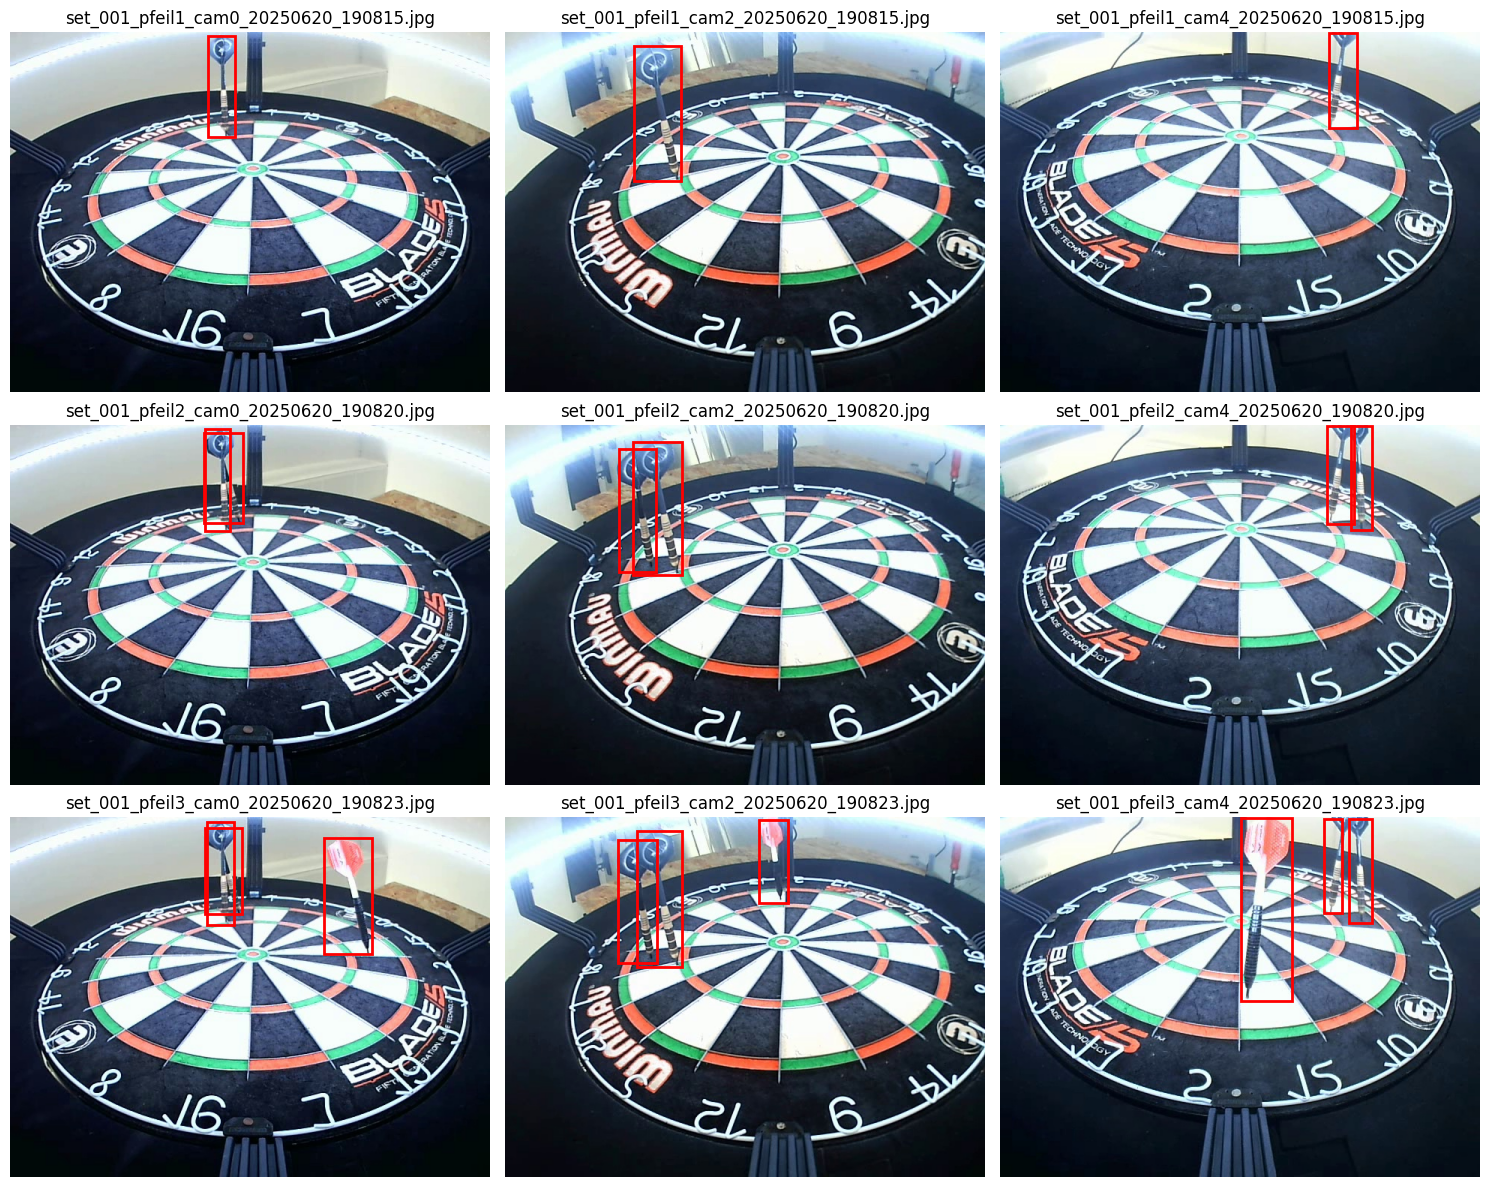

In [117]:
# Visualize one samples
sample_set = [d for d in all_data if d["set_id"] == "set_001"]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))
for i, data in enumerate(sample_set[:9]):
    img = Image.open(data["image_path"])
    ax = axs[i // 3, i % 3]
    ax.imshow(img)
    ax.set_title(os.path.basename(data["image_path"]))
    
    for box in data["bboxes"]:
        x, y, w, h = box["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# structure the data by set_id and pfeil_nr
data_by_set = defaultdict(lambda: defaultdict(list))

# Iterate over all data and group by set_id and pfeil_nr
for entry in all_data:
    set_id = entry["set_id"]
    pfeil_nr = f"pfeil{entry['pfeil_nr']}"
    data_by_set[set_id][pfeil_nr].append(entry)

# Function to extract camera number from the image path
def extract_cam_number(path):
    basename = os.path.basename(path)
    if "_cam0" in basename: return 0
    if "_cam2" in basename: return 2
    if "_cam4" in basename: return 4
    return -1  # fallback

for set_data in data_by_set.values():
    for pfeil, entries in set_data.items():
        entries.sort(key=lambda e: extract_cam_number(e["image_path"]))

# Example usage: print the data for a specific set_id and pfeil_nr
example_set = "set_001"
for pfeil_nr, cams in data_by_set[example_set].items():
    print(f"{example_set} - {pfeil_nr}: {[os.path.basename(c['image_path']) for c in cams]}")

set_001 - pfeil1: ['set_001_pfeil1_cam0_20250620_190815.jpg', 'set_001_pfeil1_cam2_20250620_190815.jpg', 'set_001_pfeil1_cam4_20250620_190815.jpg']
set_001 - pfeil2: ['set_001_pfeil2_cam0_20250620_190820.jpg', 'set_001_pfeil2_cam2_20250620_190820.jpg', 'set_001_pfeil2_cam4_20250620_190820.jpg']
set_001 - pfeil3: ['set_001_pfeil3_cam0_20250620_190823.jpg', 'set_001_pfeil3_cam2_20250620_190823.jpg', 'set_001_pfeil3_cam4_20250620_190823.jpg']


In [134]:
class DartDataset(Dataset):
    def __init__(self, data_by_set, score_classes, zone_classes, transform=None):
        self.samples = []
        self.transform = transform if transform else T.ToTensor()

        for set_id, pfeile in data_by_set.items():
            for pfeil_nr, cams in pfeile.items():
                if len(cams) != 3:
                    continue  # weniger als 3 Cams

                # Prüfen, ob in allen 3 Kameras eine BBox vorhanden ist
                if any(len(c["bboxes"]) == 0 for c in cams):
                    continue

                # Annahme: gleiche Labels für alle 3 Bilder
                score = cams[0]["bboxes"][0]["score"]
                zone = cams[0]["bboxes"][0]["zone"]
                score_cls = score_classes[score]
                zone_cls = zone_classes[zone]

                self.samples.append({
                    "images": [c["image_path"] for c in cams],
                    "bboxes": [c["bboxes"][0]["bbox"] for c in cams],
                    "score_cls": score_cls,
                    "zone_cls": zone_cls
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image_tensors = []

        for img_path, bbox in zip(sample["images"], sample["bboxes"]):
            img = Image.open(img_path).convert("RGB")
            x, y, w, h = map(int, bbox)
            crop = img.crop((x, y, x + w, y + h))
            crop = self.transform(crop)
            image_tensors.append(crop)

        return {
            "images": torch.stack(image_tensors),  # Shape: (3, C, H, W)
            "score_cls": sample["score_cls"],
            "zone_cls": sample["zone_cls"]
        }

In [135]:
all_scores = sorted({box["score"] for entry in all_data for box in entry["bboxes"]})
all_zones = sorted({box["zone"] for entry in all_data for box in entry["bboxes"]})

score_classes = {v: i for i, v in enumerate(all_scores)}
zone_classes = {v: i for i, v in enumerate(all_zones)}

 

In [144]:
transform = T.Compose([
    T.Resize((width,height)),  # oder andere Größe später
    T.ToTensor()
])


In [148]:
all_valid_shots = []
for set_id, pfeile in data_by_set.items():
    for pfeil_nr, cams in pfeile.items():
        if len(cams) == 3 and all(len(c["bboxes"]) > 0 for c in cams):
            all_valid_shots.append((set_id, pfeil_nr))

print(f"✅ Gesamtanzahl gültiger Pfeile: {len(all_valid_shots)}")
train_shots, test_shots = train_test_split(all_valid_shots, test_size=0.2, random_state=42)


✅ Gesamtanzahl gültiger Pfeile: 639


In [145]:
class DartNet(nn.Module):
    def __init__(self, num_score_classes, num_zone_classes):
        super().__init__()

        # Backbone: z. B. ResNet18 (ohne letzte FC-Schicht)
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])  # (B, 512, 1, 1)

        # Zwei Klassifikatoren
        self.score_head = nn.Linear(512, num_score_classes)
        self.zone_head = nn.Linear(512, num_zone_classes)

    def forward(self, x):
        # x: (B, 3, C, H, W)
        cams = torch.unbind(x, dim=1)  # Liste mit 3 Tensoren (B, C, H, W)
        features = [self.feature_extractor(cam).squeeze(-1).squeeze(-1) for cam in cams]  # (B, 512)
        fused = torch.mean(torch.stack(features, dim=0), dim=0)  # (B, 512)

        score_out = self.score_head(fused)  # (B, num_scores)
        zone_out = self.zone_head(fused)    # (B, num_zones)

        return score_out, zone_out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DartNet(num_score_classes=len(score_classes), num_zone_classes=len(zone_classes)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# DataLoader

c:\Users\sophi\Desktop\AutoBull\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\Desktop\AutoBull\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [142]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        imgs = batch["images"].to(device)              # (B, 3, C, H, W)
        score_labels = batch["score_cls"].to(device)   # (B,)
        zone_labels = batch["zone_cls"].to(device)     # (B,)

        optimizer.zero_grad()
        score_out, zone_out = model(imgs)

        loss_score = criterion(score_out, score_labels)
        loss_zone = criterion(zone_out, zone_labels)
        loss = loss_score + loss_zone

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"🔁 Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

KeyboardInterrupt: 